# User Funnel Drop-off Analysis

## Problem Statement
        The objective of this assessment is to analyze user funnel event data and identify where users are dropping off during the signup and purchase process.

    The analysis includes:
        • Data inspection

        • Data quality checks

        • Stage-wise unique user analysis

        • Conversion rate calculation

        • Drop-off analysis

        • Visualization

        • Business recommendations

### Importing Libraries

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

### Load Dataset

In [16]:
df = pd.read_csv(r"C:\Users\SANDESH\Downloads\funnel_events_sample.csv")

df.head()

,user_id,step,timestamp
0,U082,visited_site,2026-07-20 04:08:00
1,U072,email_verified,2026-07-20 04:53:00
2,U041,signup_started,2026-07-20 04:09:00
3,U034,visited_site,2026-07-20 04:00:00
4,U052,visited_site,2026-07-20 04:03:00


### Dataset Overview

In [3]:
df.tail()

,user_id,step,timestamp
537,U131,purchase_completed,2026-07-20 04:53:00
538,U156,details_filled,2026-07-20 04:15:00
539,U067,signup_started,2026-07-20 04:11:00
540,U033,details_filled,2026-07-20 04:08:00
541,U163,details_filled,2026-07-20 04:05:00


In [4]:
df.sample(10)

,user_id,step,timestamp
352,U104,purchase_completed,2026-07-20 04:33:00
97,U024,details_filled,2026-07-20 04:21:00
171,U150,visited_site,2026-07-20 03:39:00
285,U193,visited_site,2026-07-20 04:03:00
129,U049,signup_started,2026-07-20 04:21:00
528,U165,visited_site,2026-07-20 03:55:00
20,U076,visited_site,2026-07-20 04:04:00
45,U022,visited_site,2026-07-20 03:51:00
520,U059,signup_started,2026-07-20 04:03:00
305,U099,signup_started,2026-07-20 03:47:00


In [5]:
df.shape

(542, 3)

### Information of Dataset

In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 542 entries, 0 to 541
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   user_id    542 non-null    object
 1   step       542 non-null    object
 2   timestamp  542 non-null    object
dtypes: object(3)
memory usage: 12.8+ KB


### 5 Number Summury

In [18]:
df.describe(include='all')

,user_id,step,timestamp
count,542,542,542
unique,200,5,94
top,U082,visited_site,2026-07-20 04:01:00
freq,3,200,15


### Checking Null Values

In [19]:
df.isnull().sum()

user_id      0
step         0
timestamp    0
dtype: int64

### Checking Duplicates

In [14]:
df.duplicated().sum()

np.int64(0)

In [22]:
df['user_id'].nunique()

200

### Data type Changed Separated Into columns

In [21]:
df["timestamp"] = pd.to_datetime(df["timestamp"])


In [23]:
df["date"] = df["timestamp"].dt.date
df["time"] = df["timestamp"].dt.time

df.head()

,user_id,step,timestamp,date,time
0,U082,visited_site,2026-07-20 04:08:00,2026-07-20,04:08:00
1,U072,email_verified,2026-07-20 04:53:00,2026-07-20,04:53:00
2,U041,signup_started,2026-07-20 04:09:00,2026-07-20,04:09:00
3,U034,visited_site,2026-07-20 04:00:00,2026-07-20,04:00:00
4,U052,visited_site,2026-07-20 04:03:00,2026-07-20,04:03:00


In [90]:
df["Hour"] = df["timestamp"].dt.hour
df['Hour'].head()

0    4
1    4
2    4
3    4
4    4
Name: Hour, dtype: int32

In [88]:
df["Day"] = df["timestamp"].dt.day_name()
df['Day'].head()

0    Monday
1    Monday
2    Monday
3    Monday
4    Monday
Name: Day, dtype: object

### Funnel Analysis

In [24]:
steps = [
    "visited_site",
    "signup_started",
    "details_filled",
    "email_verified",
    "purchase_completed"
]

counts = (
    df.groupby("step")["user_id"].nunique().reindex(steps)
   )

counts

step
visited_site          200
signup_started        150
details_filled         96
email_verified         52
purchase_completed     44
Name: user_id, dtype: int64

In [25]:
result = pd.DataFrame()

result["Users"] = counts.values

result.index = steps

result

,Users
visited_site,200
signup_started,150
details_filled,96
email_verified,52
purchase_completed,44


### Conversion Rate Analysis

In [26]:
conversion = [100]

for i in range(1, len(counts)):
    conversion.append( round(counts.iloc[i] / counts.iloc[i-1] * 100,2)
              )

result["Conversion Rate (%)"] = conversion

result

,Users,Conversion Rate (%)
visited_site,200,100.00
signup_started,150,75.00
details_filled,96,64.00
email_verified,52,54.17
purchase_completed,44,84.62


### Drop off Analysis

In [27]:
drop = [0]

for i in range(1, len(counts)):
    drop.append(
        counts.iloc[i-1] -
        counts.iloc[i]
    )

result["Drop-off"] = drop

result

,Users,Conversion Rate (%),Drop-off
visited_site,200,100.00,0
signup_started,150,75.00,50
details_filled,96,64.00,54
email_verified,52,54.17,44
purchase_completed,44,84.62,8


In [28]:
ldrop = result["Drop-off"].idxmax()

ldrop

'details_filled'

### Visualization

In [70]:
result = pd.DataFrame({
    "Stage": counts.index,
    "Users": counts.values,
    "Conversion Rate (%)":conversion,
    "Drop-off" : drop    
} )

result

,Stage,Users,Conversion Rate (%),Drop-off
0,visited_site,200,100.00,0
1,signup_started,150,75.00,50
2,details_filled,96,64.00,54
3,email_verified,52,54.17,44
4,purchase_completed,44,84.62,8


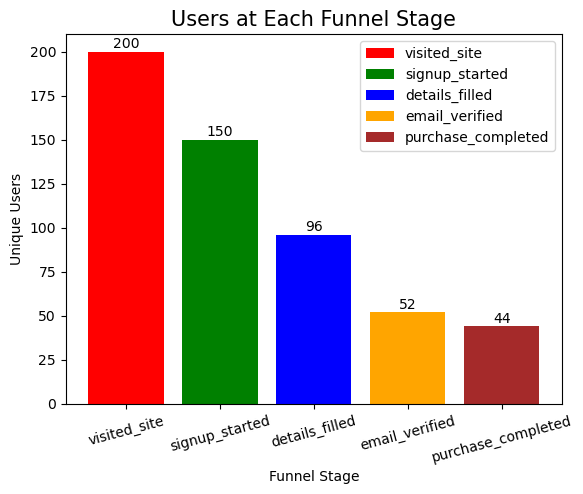

In [66]:
c=['red','green','blue','orange','brown']

plt.bar(result['Stage'],result["Users"],color=c ,label=result['Stage'])

plt.title("Users at Each Funnel Stage",color='black',fontsize=15)

plt.xlabel("Funnel Stage")

plt.ylabel("Unique Users")

plt.xticks(rotation=15)

for i, value in enumerate(result["Users"]):
    plt.text(i, value+2, str(value), ha="center")

plt.legend()

plt.show()

### Conversion Rate Analysis

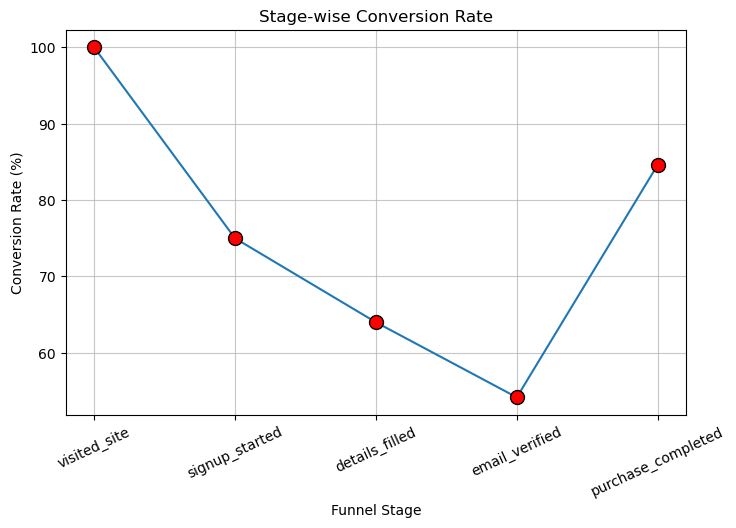

In [82]:
plt.figure(figsize=(8,5))

plt.plot(
    result["Stage"],
    result["Conversion Rate (%)"],
    marker="o",
    mfc='red',
    mec='black',
    ms=10
)

plt.title("Stage-wise Conversion Rate")

plt.xlabel("Funnel Stage")

plt.ylabel("Conversion Rate (%)")

plt.grid(alpha=0.7)

plt.xticks(rotation=25)

plt.show()

### Drop-off Analisis

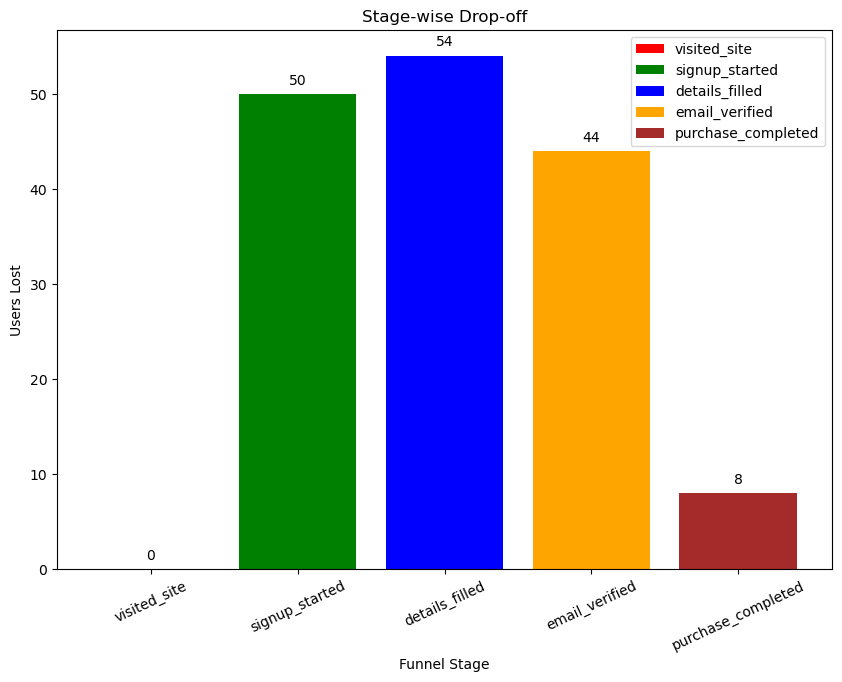

In [80]:
plt.figure(figsize=(10,7))
c=['red','green','blue','orange','brown']

plt.bar(result['Stage'],result["Drop-off"],color=c ,label=result['Stage'])
plt.title("Stage-wise Drop-off")

plt.xlabel("Funnel Stage")

plt.ylabel("Users Lost")

plt.xticks(rotation=25)

for i, value in enumerate(result["Drop-off"]):
    plt.text(i, value+1, str(value), ha="center")

plt.legend(loc='best')
plt.show()

In [91]:
largest_drop = result.loc[result["Drop-off"].idxmax()]

print("Biggest Drop-off Stage :", largest_drop["Stage"])
print("Users Lost :", largest_drop["Drop-off"])
print("Conversion Rate :", largest_drop["Conversion Rate (%)"],"%")

Biggest Drop-off Stage : details_filled
Users Lost : 54
Conversion Rate : 64.0 %


In [92]:
df

,user_id,step,timestamp,date,time,Hour,Day
0,U082,visited_site,2026-07-20 04:08:00,2026-07-20,04:08:00,4,Monday
1,U072,email_verified,2026-07-20 04:53:00,2026-07-20,04:53:00,4,Monday
2,U041,signup_started,2026-07-20 04:09:00,2026-07-20,04:09:00,4,Monday
3,U034,visited_site,2026-07-20 04:00:00,2026-07-20,04:00:00,4,Monday
4,U052,visited_site,2026-07-20 04:03:00,2026-07-20,04:03:00,4,Monday
...,...,...,...,...,...,...,...
537,U131,purchase_completed,2026-07-20 04:53:00,2026-07-20,04:53:00,4,Monday
538,U156,details_filled,2026-07-20 04:15:00,2026-07-20,04:15:00,4,Monday
539,U067,signup_started,2026-07-20 04:11:00,2026-07-20,04:11:00,4,Monday
540,U033,details_filled,2026-07-20 04:08:00,2026-07-20,04:08:00,4,Monday


### Summary
• A total of 200 users visited the website.

• Only 44 users completed the purchase.

• The highest drop-off occurred between Signup Started and Details Filled.

• This indicates users abandon the registration process before completing their details.

• Improving the signup experience could significantly increase conversions.

### Business Insights
    The funnel analysis shows a steady decline in users at each stage, with an overall conversion rate of 22% (44 out of 200 visitors completed a purchase).

    The largest drop-off (54 users, 36%) occurs between "Signup Started" and "Details Filled." This suggests users begin registration but abandon it before completing their profile details — likely due to a long or complex form, unclear instructions, or a request for unnecessary/sensitive information at this stage.
    
    A secondary drop-off (44 users, 46%) happens between "Details Filled" and "Email Verified," indicating some users may be losing interest during the verification step, possibly due to email delays or a confusing verification process.



### Recommendations:
    Simplify the "Details Filled" form — reduce the number of required fields or split it into shorter steps.

    Add a progress indicator so users know how many steps remain.

    Send verification emails instantly and consider adding a "resend" or alternate verification option (e.g., OTP via SMS) to reduce drop-off at that stage.
    
    A/B test a shorter signup form against the current one to validate if simplification improves conversion.
